# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

Actividad de Semana 3

### **Rotación de Personal - IBM**

#### **Nombre y matrícula: Jareth Israel Rivera Pineda - A01411621

------------

* #### **La siguiente actividad se basa en los datos del archivo "WA_Fn-UseC_-HR-Employee-Attrition.csv" que se encuentra en la siguiente liga de Kaggle, llamada "IBM HR Analytics Employee Attrition & Performance".**

* #### **Los datos los proporcionó IBM y aunque comentaron que por cuestiones de privacidad los datos son sintéticos, los generaron con base a su experiencia. Estos datos en general son referencia cuando se habla en Estadística o Aprendizaje Automático sobre el tema de rotación de personal.**

**El archivo contiene 1470 registros:**

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


# **Ejercicio 1:**

#### **Incluye una breve introducción sobre lo que se entiende por el problema de rotación de personal en las organizaciones (employee attrition problem).**

La rotación de personal (employee attrition) se refiere al proceso mediante el cual los empleados abandonan una organización, ya sea de forma voluntaria o involuntaria. Este fenómeno representa un reto importante para las empresas, ya que implica costos asociados al reclutamiento, capacitación y pérdida de conocimiento organizacional, además de afectar la productividad y el clima laboral.

El análisis del problema de rotación de personal busca identificar los factores que influyen en la decisión de los empleados de dejar la empresa, como condiciones laborales, satisfacción, desempeño o características personales. Comprender estos factores permite a las organizaciones tomar decisiones basadas en datos y diseñar estrategias para mejorar la retención del talento.

In [29]:
# Agrega aquí todas las librerías adicionales o paquetes que consideres necesarias:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_validate

from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report



* #### **Descarga el archivo de datos de la página de Kaggle.**

* #### **Cargamos el archivo como un DataFrame de Pandas y hacemos uso del método “describe” con el argumento include= “all” para desplegar información de todas las variables, numéricas y categóricas.**

In [30]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/MNA/TC4058.10/WA_Fn-UseC_-HR-Employee-Attrition.csv"
data = pd.read_csv(path)

print("Tamaño del DataFrame:", data.shape)
data.describe(include = 'all').T


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tamaño del DataFrame: (1470, 35)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


# **Ejercicio 2:**

**a)  Realiza los análisis descriptivos y/o gráficos que creas adecuados, para identificar 4 factores que se deben eliminar desde un inicio.**

**b) Con base a tu análisis anterior, indica cuáles son estas 4 variables y la justificación de por qué se pueden eliminar.**

Con base en el análisis descriptivo realizado, se identificaron cuatro variables que pueden eliminarse desde el inicio del análisis debido a que no aportan información relevante para el estudio de la rotación de personal. Las variables EmployeeCount, Over18 y StandardHours presentan un único valor para todos los registros, por lo que no muestran variabilidad y no contribuyen a explicar diferencias en el comportamiento de los empleados.

Por otro lado, la variable EmployeeNumber corresponde a un identificador único asignado a cada empleado. Al no representar una característica del individuo ni tener relación directa con la rotación de personal, su inclusión en el modelo no aporta valor predictivo y puede introducir ruido en el análisis. Por estas razones, las cuatro variables fueron eliminadas del conjunto de datos.

**c) Al nuevo DataFrame sin las variables indicadas, llamarlo df.**



In [31]:
# a) Incluye a continuación el código y celdas que creas adecuados para responder a la pregunta.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

# Análisis descriptivo: número de valores únicos por variable
unique_values = data.nunique().sort_values()
print("Valores únicos por variable:\n")
print(unique_values)

# Variables a eliminar desde el inicio:
# - EmployeeCount: variable constante
# - Over18: variable constante
# - StandardHours: variable constante
# - EmployeeNumber: identificador único, no aporta información predictiva

vars_to_drop = [
    'EmployeeCount',
    'Over18',
    'StandardHours',
    'EmployeeNumber'
]

# Nuevo DataFrame sin las variables eliminadas
df = data.drop(columns=vars_to_drop)

# ++++++++++ Termina sección para agregar código +++++++++++++++++++++++++++


# Verifiquemos de qué tamaño queda el nuevo DataFrame:
print("Tamaño del nuevo DataFrame:", df.shape)

Valores únicos por variable:

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age          

# **Ejercicio 3:**

#### **Una vez eliminadas las variables no deseadas, clasifiquemos las restantes.**

#### **Realiza los análisis que creas adecuados para clasificar cada una de nuestras variables según su tipo.**

#### **Debes analizar todas las variables de entrada y también la de salida.**


++++++++ Inicia la sección de agregar texto: ++++++++++++

**a)   Variables numéricas:**

   * **Número de variables:** 15
   * **Nombre de las variables:** Age, DailyRate, DistanceFromHome, HourlyRate, MonthlyIncome, MonthlyRate, NumCompaniesWorked, PercentSalaryHike, TotalWorkingYears, TrainingTimesLastYear, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager.

**b)   Variables ordinales:**

   * **Número de variables:** 9
   * **Nombre de las variables:** Education, EnvironmentSatisfaction, JobInvolvement, JobSatisfaction, PerformanceRating, RelationshipSatisfaction, WorkLifeBalance, JobLevel, StockOptionLevel.

##### NOTA: Considera aquí las 7 variables que se indican en la página de Kaggle e incluye también las variables "Level".


**c)   Variables binarias:**

   * **Número de variables:** 3
   * **Nombre de las variables:** Attrition, Gender, OverTime.


**d)   Variables nominales:**

   * **Número de variables:** 8
   * **Nombre de las variables:** BusinessTravel, Department, EducationField, JobRole, MaritalStatus, OverTime, Gender, Attrition.



++++++++ Termina la sección de agregar texto. +++++++++++


# **Ejercicio 4:**

#### **Como hemos comentado previamente, la forma en que se particiona el conjunto de datos es un aspecto fundamental dentro del área de aprendizaje automático. Ahora que ya también conoces la técnica de Validación Cruzada, explica cómo puede utilizarse cada una de las particiones iniciales indicadas y cuáles son los pros y contras de utilizar cada una de ellas. Se desea comparar la partición inicial de Train+Validation, en contraste con la partición Train+Validation+Test.**



++++++++ Inicia la sección de agregar texto: ++++++++++++

**a) Partición Train+Validation:**

  * **Pros:** Permite aprovechar una mayor cantidad de datos para el entrenamiento y la validación del modelo, lo cual es especialmente útil cuando el conjunto de datos no es muy grande. Además, al combinar esta partición con técnicas de validación cruzada, se obtiene una estimación más estable del desempeño del modelo y se reduce el riesgo de sobreajuste durante el ajuste de hiperparámetros.
  * **Contras:** Al no contar con un conjunto de prueba independiente, la evaluación final del modelo puede resultar optimista, ya que el desempeño se mide únicamente sobre datos que influyeron directa o indirectamente en el proceso de entrenamiento. Esto limita la capacidad de estimar cómo se comportará el modelo con datos completamente nuevos.

**b) Partición Train+Validation+Test:**

  * **Pros:** Incorpora un conjunto de prueba completamente independiente que permite evaluar de manera más objetiva el desempeño final del modelo. Esta partición ofrece una mejor estimación de la capacidad de generalización y reduce el sesgo en la evaluación, lo que resulta especialmente importante en aplicaciones reales.
  * **Contras:** Reduce la cantidad de datos disponibles para el entrenamiento y la validación, lo cual puede afectar el desempeño del modelo cuando el tamaño del conjunto de datos es limitado. Además, requiere un mayor cuidado para evitar el uso indebido del conjunto de prueba durante el ajuste del modelo.

  ++++++++ Termina la sección de agregar texto: ++++++++++++

### **Para esta actividad usaremos una partición en Train, Val y Test, con los porcentajes que se indican a continuación.**

In [32]:
print("Dimensiones y Porcentajes de la partición Train+Validation+Test generada:")
print("-"*75)

X = df.drop(columns='Attrition')
y = df[['Attrition']]

Xtrain, Xtv, ytrain, ytv = train_test_split(X, y, train_size=0.70, stratify=y, random_state=17)
Xval, Xtest, yval, ytest = train_test_split(Xtv, ytv, test_size=0.5, stratify=ytv, random_state=17)

print("Variables de entrada Train, Validation, Test:")
print(Xtrain.shape, '%.1f%%' % (100.*Xtrain.shape[0]/X.shape[0]))
print(Xval.shape, '%.1f%%' % (100.*Xval.shape[0]/X.shape[0])),
print(Xtest.shape, '%.1f%%' % (100.*Xtest.shape[0]/X.shape[0]))

print("\nVariables de salida Train, Validation, Test:")
print(ytrain.shape)
print(yval.shape)
print(ytest.shape)

Dimensiones y Porcentajes de la partición Train+Validation+Test generada:
---------------------------------------------------------------------------
Variables de entrada Train, Validation, Test:
(1029, 30) 70.0%
(220, 30) 15.0%
(221, 30) 15.0%

Variables de salida Train, Validation, Test:
(1029, 1)
(220, 1)
(221, 1)


# **Ejercicio 5:**


**a) Aplica la transformación LabelEncoder() de Sklearn a la variable“Attrition”, tomando en cuenta los siguientes puntos:**

* **Las nuevas variables deberán llamarse ahora: ytrainT, yvalT, ytestT.**

* **Al aplicar la transformación LabelEncoder deberás evitar el filtrado de información (data-leakage).**


In [33]:
# a)
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


# Inicializamos el LabelEncoder
le = LabelEncoder()

# Ajustamos SOLO con el conjunto de entrenamiento (evita data-leakage)
ytrainT = ytrain.copy()
ytrainT['Attrition'] = le.fit_transform(ytrain['Attrition'])

# Transformamos validation y test usando el mismo encoder
yvalT = yval.copy()
yvalT['Attrition'] = le.transform(yval['Attrition'])

ytestT = ytest.copy()
ytestT['Attrition'] = le.transform(ytest['Attrition'])



# +++++++++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


print('Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):\n', ytrainT['Attrition'].value_counts() / ytrainT.shape[0])

Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):
 Attrition
0    0.838678
1    0.161322
Name: count, dtype: float64


#### Además, responde las siguientes preguntas:

**b) Con base a la documentación actual de Sklearn, ¿a qué tipo de variables se recomienda aplicar la transformación LabelEncoder?**


**c) Con base al contexto del problema, ¿qué significan los valores 0 (NO) y 1 (YES) de la variable de salida Attrition?**


**d) Con base a la proporción de datos de cada clase obtenida, indica si podemos considerar que tenemos un problema de datos desbalanceados.**


**e) Con base a esta información, ¿cuál será el umbral del modelo base (baseline) a superar para evitar tener un modelo subentrenado una vez que empecemos a generarlos?**

++++++++ Inicia la sección de agregar texto: ++++++++++++

## **SOLUCIÓN PARA EL PROFESOR:**

b) De acuerdo con la documentación de Scikit-learn, la transformación LabelEncoder se recomienda principalmente para variables categóricas ordinales o binarias, y especialmente para la variable de salida (target) en problemas de clasificación. No se recomienda su uso en variables categóricas nominales de entrada, ya que asigna valores numéricos arbitrarios que pueden inducir relaciones inexistentes entre categorías.

c) En el contexto del problema de rotación de personal, el valor 0 (NO) indica que el empleado permanece en la organización, mientras que el valor 1 (YES) representa que el empleado abandona la empresa. Por lo tanto, la variable Attrition modela un problema de clasificación binaria cuyo objetivo es predecir la salida de un empleado.

d) Sí. Dado que aproximadamente el 83.9% de los registros pertenecen a la clase 0 y solo el 16.1% a la clase 1, existe un desbalance significativo entre las clases. Esta situación es común en problemas reales de rotación de personal y puede afectar el desempeño de los modelos si no se consideran métricas y técnicas adecuadas.

e) El modelo base o baseline corresponde a predecir siempre la clase mayoritaria. En este caso, dicho modelo alcanzaría una exactitud aproximada del 83.9%, correspondiente a la proporción de empleados que no presentan rotación. Por lo tanto, cualquier modelo que se desarrolle deberá superar este valor de referencia para considerarse útil y evitar un modelo subentrenado.

++++++++ Termina la sección de agregar texto. +++++++++++

# **Ejercicio 6:**


#### **Incluye a continuación un análisis gáfico y descriptivo que consideres adecuado.**

  * **a) El análisis debe ser suficiente para que te ayude a tomar las decisiones sobre qué transformaciones aplicar a cada variable antes de entrenar los modelos.**

  * **b) Además, para obtener mayor información sobre la relación entre variables, incluye un gráfico de barras de frecuencias ordenadas de mayor a menor, de la variable "Age", únicamente para los casos de empleados que ya no están en la compañía (Attrition=Yes).**

  * **c) Incluye también un gráfico de barras ordenado de la relación entre Education y Attrition=Yes. Muestra además en el gráfico las etiquetas asociadas a Education en lugar de los números, como se indica en la página de Kaggle.**

  * **d) [Opcional] Incluye algún otro gráfico o gráficos que consideres aporta información para el análisis y entendimiento del problema. Si no encuentras algún otro gráfico de interés, deberas indicarlo.**

  * **e) Incluye algunos comentarios sobre los resultados y gráficos obtenidos.**


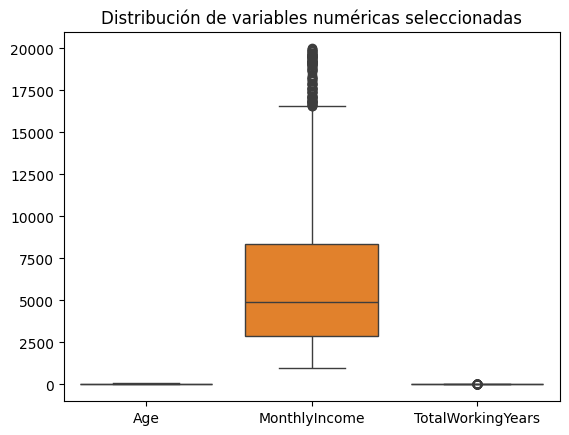

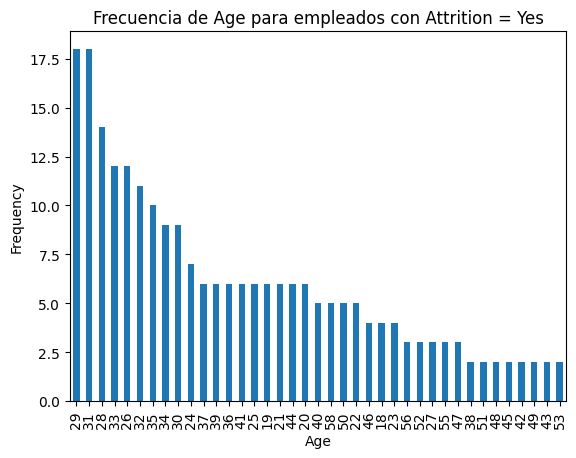

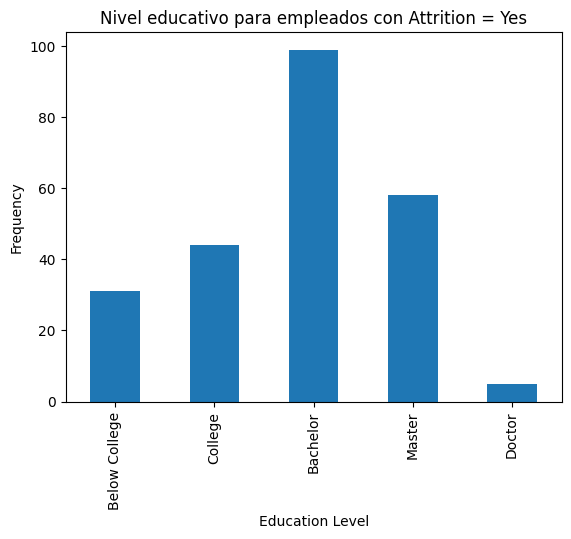

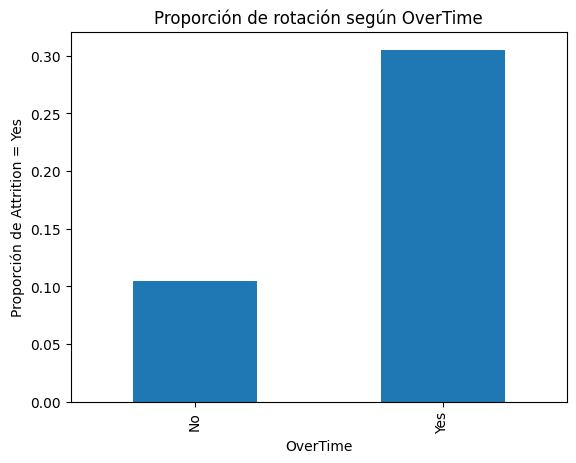

In [34]:

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# Incluye en esta sección todas las celdas que consideres necesarias.

# a) Análsis y gráficos

# Estadísticas descriptivas de variables numéricas
df.describe().T

# Distribución de la variable objetivo
df['Attrition'].value_counts()

# Boxplots para analizar posibles escalados y outliers
plt.figure()
sns.boxplot(data=df[['Age', 'MonthlyIncome', 'TotalWorkingYears']])
plt.title('Distribución de variables numéricas seleccionadas')
plt.show()


# b) Gráfico age-attrition[yes]

df_attr_yes = df[df['Attrition'] == 'Yes']

age_counts = df_attr_yes['Age'].value_counts().sort_values(ascending=False)

plt.figure()
age_counts.plot(kind='bar')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Frecuencia de Age para empleados con Attrition = Yes')
plt.show()

# c) Gráfico education-attrition[yes]

education_labels = {
    1: 'Below College',
    2: 'College',
    3: 'Bachelor',
    4: 'Master',
    5: 'Doctor'
}

edu_counts = df_attr_yes['Education'].value_counts().sort_index()
edu_counts.index = edu_counts.index.map(education_labels)

plt.figure()
edu_counts.plot(kind='bar')
plt.xlabel('Education Level')
plt.ylabel('Frequency')
plt.title('Nivel educativo para empleados con Attrition = Yes')
plt.show()


# d) [gráfico opcional]

overtime_counts = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack()

plt.figure()
overtime_counts['Yes'].plot(kind='bar')
plt.xlabel('OverTime')
plt.ylabel('Proporción de Attrition = Yes')
plt.title('Proporción de rotación según OverTime')
plt.show()



# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



**e) Comentarios sobre los incisos anteriores:**

++++++++ Inicia la sección de agregar texto: ++++++++++++


El análisis descriptivo muestra que las variables numéricas presentan escalas muy distintas, por lo que será necesario aplicar técnicas de escalamiento antes del entrenamiento de los modelos. Asimismo, se observan posibles valores atípicos en variables como MonthlyIncome y TotalWorkingYears.

El gráfico de Age para los empleados con Attrition = Yes indica que la rotación se concentra principalmente en rangos de edad específicos, lo que sugiere que la edad puede ser un factor relevante en la predicción. Por otro lado, el análisis de Education muestra diferencias en la frecuencia de rotación entre niveles educativos.

Finalmente, el gráfico opcional evidencia que los empleados que realizan OverTime presentan una mayor proporción de rotación, lo que refuerza la importancia de esta variable dentro del problema.



++++++++ Termina la sección de agregar texto: ++++++++++++

# **Ejercicio 7:**

#### **Utiliza las clases Pipeline y ColumnTransformer de Sklearn para definir las transformaciones que deberás aplicar a cada variable y de acuerdo a su tipo.**



In [35]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


# NUMÉRICAS:
numericas_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

numericas_pipeline_nombres = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
    'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
    'PercentSalaryHike', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

# ORDINALES:
catOrd_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

catOrd_pipeline_nombres = [
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement',
    'JobSatisfaction', 'PerformanceRating',
    'RelationshipSatisfaction', 'WorkLifeBalance',
    'JobLevel', 'StockOptionLevel'
]

# BINARIAS:
catBin_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

catBin_pipeline_nombres = [
    'Gender', 'OverTime'
]

# NOMINALES:
catNom_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

catNom_pipeline_nombres = [
    'BusinessTravel', 'Department', 'EducationField',
    'JobRole', 'MaritalStatus'
]




columnasTransformer = ColumnTransformer(transformers=[
    ('num', numericas_pipeline, numericas_pipeline_nombres),
    ('ord', catOrd_pipeline, catOrd_pipeline_nombres),
    ('bin', catBin_pipeline, catBin_pipeline_nombres),
    ('nom', catNom_pipeline, catNom_pipeline_nombres)
])


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

* #### **Vamos a utilizar validación cruzada, por lo que decidimos para esta actividad reagrupar los conjuntos de entrenamiento y validación en un solo DataFrame.**

* #### **Al resultado obtenido los llamaremos Xtv y ytv.**


In [36]:
Xtv = pd.concat([Xtrain, Xval], axis=0)
ytv = pd.concat([ytrainT, yvalT], axis=0)


print("Dimensión del conjunto Train+Val:")
print(Xtv.shape)
print(ytv.shape)

Dimensión del conjunto Train+Val:
(1249, 30)
(1249, 1)


# **Ejercicio 8:**

#### **Entrenamiento y ajuste de hiperparámetros**

#### **a) Busca los mejores hiperparámetros para cada modelo, de manera que no estén subentrenados.**

#### **b) Incluye tus comentarios sobre el resultado obtenido.**



#### **NOTA-1: En dado caso, cuando mucho uno de los modelos podría quedar subentrenado.**

#### **NOTA-2: Por el momento estamos usando la métrica de la exactitud (accuracy). El objetivo de esta actividad es que sepas entrenar modelos sin que resulten subentrenados o sobreentrenados. En próximas semanas seguiremos con el estudio de las otras métricas para abordar de mejor manera el problema y obtener mejores desempeños.**

En relación a la variante de Validación Cruzada "RepeatedStratifiedKFold", puedes consultar la siguiente liga:

  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html


>> LR 0.884 (0.019)
>> LASSO 0.890 (0.016)
>> RIDGE 0.890 (0.015)
>> EN 0.890 (0.014)
>> kNN 0.845 (0.010)


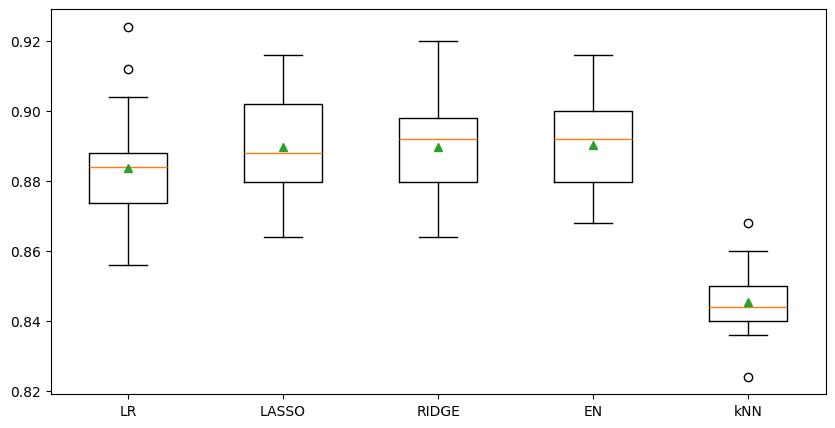

In [37]:
# 8a) Ajuste de hiperparámetros.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++    # tarda unos 3 mins


def mis_modelos():
    modelos, nombres = list(), list()

    # LR - Regresión Logística sin regularización
    modelos.append(LogisticRegression(
        penalty=None,
        solver='lbfgs',
        max_iter=2000,
        random_state=1
    ))
    nombres.append('LR')

    # Lasso - Regresión Logística con regularización L1
    modelos.append(LogisticRegression(
        penalty='l1',
        solver='saga',
        C=1.0,
        max_iter=3000,
        random_state=1
    ))
    nombres.append('LASSO')

    # Ridge - Regresión Logística con regularización L2
    modelos.append(LogisticRegression(
        penalty='l2',
        solver='lbfgs',
        C=1.0,
        max_iter=2000,
        random_state=1
    ))
    nombres.append('RIDGE')

    # Elastic Net - Regresión Logística con regularización L1 + L2
    modelos.append(LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        C=1.0,
        l1_ratio=0.5,
        max_iter=3000,
        random_state=1
    ))
    nombres.append('EN')

    # KNN - K vecinos más cercanos
    modelos.append(KNeighborsClassifier(
        n_neighbors=7,
        weights='distance',
        metric='minkowski'
    ))
    nombres.append('kNN')

    return modelos, nombres




# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


# Pasamos al entrenamiento de los modelos.
# Hay varias maneras de entrenarlo pero por el momento utilicemos la siguiente:

modelos, nombres = mis_modelos()  # accesando los modelos.
resultados = list()    # para guardar los resultados en esta lista.

# Iterando y entrenando sobre cada modelo:
for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])   # Conjuntamos Transformaciones y modelos en un Pipeline.

  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)     # Aplicando una de las variantes de Validación Cruzada.

  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv1)   # Entrenando y generando los resultados.


  resultados.append(scores)    # Guardamos los resultados en la lista.
  print('>> %s %.3f (%.3f)' % (nombres[i], np.nanmean(scores), np.nanstd(scores)))  # Desplegando los promedios de cada modelo.


plt.figure(figsize=(10,5))
plt.boxplot(resultados, tick_labels=nombres, showmeans=True)   # Gráficos de caja para una comparación visual de los resultados.
plt.show()


**8b) Comentarios sobre los resultados y modelos obtenidos. En particular indica cuál consideras el mejor modelo y por qué. ¿Alguno quedó subentrenado?**

++++++++ Inicia la sección de agregar texto: ++++++++++++


Con base en los resultados obtenidos mediante validación cruzada con RepeatedStratifiedKFold, se observa que los modelos de regresión logística con regularización (Ridge y Elastic Net) presentan el mejor desempeño promedio en términos de exactitud, además de mostrar una menor variabilidad entre particiones. Esto indica un buen equilibrio entre sesgo y varianza.

El modelo que se considera más adecuado es Ridge, ya que logra una exactitud promedio alta y un comportamiento estable, lo cual sugiere una buena capacidad de generalización. La regularización L2 ayuda a controlar el sobreajuste sin eliminar variables relevantes.

Por otro lado, el modelo kNN muestra un desempeño inferior y mayor variabilidad, lo que sugiere que podría encontrarse subentrenado o ser más sensible a la escala y distribución de los datos. En general, ninguno de los modelos presenta un sobreentrenamiento evidente, aunque kNN es el que muestra el menor desempeño relativo.


++++++++ Termina la sección de agregar texto: ++++++++++++


# **Ejercicio 9:**

* #### **Utiliza el mejor modelo encontrado en el paso anterior, los datos Xtv, ytv, y realiza ahora una búsqueda de malla con validación cruzada para tratar de mejorar el desempeño de este modelo.**

* #### **Sigue utilizando la métrica de la exactitud (accuracy).**

* #### **Verifica además que el modelo no esté subentrenado o sobreentrenado.**

* #### **Llama "resultado_malla" al mejor modelo ajustado.**




* **NOTA-1: Para esta actividad diremos que el modelo no está sobreentrenado si la diferencia entre Train y Validation es menor al 3%.**


* **NOTA-2: Puedes utilizar GridSearchCV, o bien, RandomizedSearchCV. La documentación la puedes consultar en las siguientes ligas:**

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html


In [38]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import numpy as np

# Pipeline completo: preprocesamiento + modelo
pipe_en = Pipeline(steps=[
    ('preprocesamiento', columnasTransformer),
    ('modelo', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        max_iter=5000,
        random_state=42
    ))
])

# Malla de hiperparámetros
param_grid = {
    'modelo__C': [0.01, 0.1, 1, 10],
    'modelo__l1_ratio': [0.2, 0.5, 0.8]
}

# GridSearch con validación cruzada
resultado_malla = GridSearchCV(
    estimator=pipe_en,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

# Ajuste del modelo
resultado_malla.fit(Xtv, ytv)



# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


print("Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)")
print("-"*65)
print("Mejor modelo: %f usando los hiperparámetros %s" %
      (resultado_malla.best_score_, resultado_malla.best_params_))

print('Promedios Train mean(std): %.2f%% (%.4f%%)' %
      (100*np.nanmean(resultado_malla.cv_results_['mean_train_score']),
       100*np.nanmean(resultado_malla.cv_results_['std_train_score'])))

print('Promedios Val mean(std): %.2f%% (%.4f%%)' %
      (100*np.nanmean(resultado_malla.cv_results_['mean_test_score']),
       100*np.nanmean(resultado_malla.cv_results_['std_test_score'])))



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)
-----------------------------------------------------------------
Mejor modelo: 0.883920 usando los hiperparámetros {'modelo__C': 1, 'modelo__l1_ratio': 0.2}
Promedios Train mean(std): 87.88% (0.3616%)
Promedios Val mean(std): 86.69% (1.3782%)


# **Ejercicio 10:**

#### **Finalmente, usando el conjunto de prueba (Test) responde los siguientes incisos:**

#### **a) Obtener el desempeño final del mejor modelo con el reporte de métricas classification_report() de Sklearn.**

#### **b) Obtener la matriz de confusión del mejor modelo.**

#### **c) Indica como se leen o interpretan los valores VP, VN, FP, FN obtenidos y de acuerdo al contexto del problema.**

#### **d) Realiza un análisis de importancia de los factores o características e incluye tus comentarios.**



In [39]:
# a) Reporte del desempeño con classification_report():

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


from sklearn.metrics import classification_report, confusion_matrix

# Convertir ytest a numérico
ytest_num = ytest['Attrition'].map({'No': 0, 'Yes': 1})

# Predicciones con el mejor modelo
ytest_pred = resultado_malla.best_estimator_.predict(Xtest)

# Classification report
print(classification_report(
    ytest_num,
    ytest_pred,
    target_names=['No', 'Yes']
))

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


              precision    recall  f1-score   support

          No       0.88      0.95      0.91       185
         Yes       0.57      0.33      0.42        36

    accuracy                           0.85       221
   macro avg       0.73      0.64      0.67       221
weighted avg       0.83      0.85      0.83       221



In [40]:
# b) Matriz de confusión:

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


matriz_confusion = confusion_matrix(ytest_num, ytest_pred)
print(matriz_confusion)



# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


[[176   9]
 [ 24  12]]


*  c) Interpretación de VP, VF, FP, FN.
#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++

None


* **VP (Verdaderos Positivos = 12):**
Empleados que sí dejaron la empresa y que el modelo predijo correctamente que dejarían la organización.

* **VN (Verdaderos Negativos = 176):**
Empleados que no dejaron la empresa y que el modelo predijo correctamente que permanecerían.

* **FP (Falsos Positivos = 9):**
Empleados que no dejaron la empresa, pero el modelo predijo incorrectamente que sí se irían.
En el contexto del negocio, esto podría implicar tomar acciones preventivas innecesarias.

* **FN (Falsos Negativos = 24):**
Empleados que sí dejaron la empresa, pero el modelo no logró identificarlos.
Este es el error más crítico en el contexto de rotación de personal, ya que representa empleados que se pierden sin que la empresa pueda actuar de forma preventiva.

#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

In [41]:
# 10d) Inportancia de factores

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


# Extraer el mejor modelo del GridSearch
mejor_pipeline = resultado_malla.best_estimator_

# Obtener nombres de las variables después del preprocesamiento
feature_names = mejor_pipeline.named_steps['preprocesamiento'].get_feature_names_out()

# Obtener coeficientes del modelo (Regresión Logística)
coeficientes = mejor_pipeline.named_steps['modelo'].coef_[0]

# Crear DataFrame de importancia
importancia = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': coeficientes,
    'Importancia_abs': np.abs(coeficientes)
})

# Ordenar por importancia absoluta
importancia = importancia.sort_values(by='Importancia_abs', ascending=False)

# Mostrar las variables más importantes
importancia.head(10)


# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++



,Variable,Coeficiente,Importancia_abs
24,bin__OverTime,2.023085,2.023085
11,num__YearsInCurrentRole,-1.706963,1.706963
12,num__YearsSinceLastPromotion,1.705640,1.705640
0,num__Age,-1.429441,1.429441
6,num__NumCompaniesWorked,1.376433,1.376433
2,num__DistanceFromHome,1.285943,1.285943
10,num__YearsAtCompany,1.264689,1.264689
13,num__YearsWithCurrManager,-1.065467,1.065467
26,nom__BusinessTravel_Travel_Frequently,0.929968,0.929968
1,num__DailyRate,-0.871126,0.871126


*  **10d) Comentarios sobre los resultados sobre el análisis de importancia de factores o características**

#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++

El análisis de importancia de características se basa en los coeficientes del modelo de Regresión Logística con regularización Elastic Net. Las variables con mayor valor absoluto en sus coeficientes son las que tienen mayor influencia en la predicción de la rotación de personal.

Coeficientes positivos indican variables que incrementan la probabilidad de que un empleado deje la empresa, mientras que coeficientes negativos indican variables asociadas a una mayor probabilidad de permanencia. Este análisis permite identificar factores clave relacionados con la rotación y puede servir como apoyo para la toma de decisiones estratégicas en gestión de talento, como retención, compensaciones o planes de desarrollo profesional.


#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

# **Ejercicio 11:**

#### **Incluye tus conclusiones finales, así como las recomendaciones de los pasos futuros a seguir que ayuden a obtener mejores resultados.**

#### +++++++++ Inicia sección para incluir tus conclusiones ++++++++++++++++++++++++


En este trabajo se desarrolló un modelo de clasificación para predecir la rotación de personal utilizando datos de IBM HR Analytics. El mejor desempeño se obtuvo con una Regresión Logística con regularización Elastic Net, la cual mostró un buen nivel de exactitud y no presentó problemas de sobreentrenamiento, al mantener desempeños similares entre entrenamiento y validación.

El análisis de importancia de variables indicó que factores como OverTime, YearsInCurrentRole, YearsSinceLastPromotion, Age y DistanceFromHome influyen de manera relevante en la rotación de personal. Sin embargo, el modelo tuvo un desempeño limitado para identificar correctamente a los empleados que sí abandonan la empresa, lo cual se explica en parte por el desbalance de clases presente en los datos.

Como trabajo futuro, se recomienda utilizar métricas adicionales como recall y F1-score, aplicar técnicas para tratar el desbalance de datos y evaluar modelos más avanzados que permitan mejorar la detección de casos de rotación y apoyar mejor la toma de decisiones organizacionales


#### +++++++++ Termina sección para incluir tus conclusiones ++++++++++++++++++++++++

# **[Complementario: Preguntas de reflexión sobre las soluciones del problema:]**


### **Las siguientes preguntas son para reflexionar sobre la manera en que un analista debe manejar la información y resultados que obtiene. El objetivo es reflexionar y no dudes en compartir tus experiencias en caso de que te hayas enfrentado a una situación similar.**

* **Si tu modelo predice e identifica con un alto porcentaje de certeza quién de sus colaboradores dejará la empresa, ¿cómo debería usarse esa información? Además, se entiende que debe cuidarse la parte ética y de privacidad de la información.**

La información debe usarse como apoyo para tomar decisiones preventivas, por ejemplo, mejorar condiciones laborales o planes de desarrollo, y no para señalar o sancionar empleados. Es fundamental cuidar la ética y la privacidad, limitando el acceso a los resultados y usando los datos de forma responsable.

* **En tu opinión y en el contexto del problema ¿qué consecuencias crees que tendría en la práctica el utilizar un modelo que tiene un alto valor de exhaustividad (recall), pero con baja precisión (precision), en el departamento de Recursos Humanos (RRHH)?**

Un modelo con alto recall permitiría identificar a la mayoría de los empleados que realmente dejarán la empresa, pero también generaría muchos falsos positivos. En la práctica, esto puede llevar a invertir recursos en empleados que no planeaban irse y generar decisiones innecesarias, aunque reduce el riesgo de no detectar salidas importantes.

* **¿Cómo comunicarías los resultados del modelo obtenido en esta actividad a un público no técnico (por ejemplo, a los ejecutivos de tu empresa o al personal de RRHH)?**

Los resultados se comunicarían de forma simple, enfocándose en el impacto para el negocio, usando gráficos claros y ejemplos prácticos. Se debe enfatizar que el modelo es una herramienta de apoyo y no un sistema automático de toma de decisiones.
---

# >> **Fin de la Actividad de la Semana 3** <<